# Recursive submodule refinement & Full workflow:
In this notebook we test the recursive submodule refinement and try to run the full workflow including refinement and multistarts. 

TODO - handover: 
- figure out how to optimize/ improve performance -> why is undirected so much slower??
- move remaining functions to infomap_funcs.py, consider splitting up and restructuring the functions
- remove function definitions from notebooks
- rename recursion notebook
- also test the nonuniform teleportation!

In [1]:
# library imports
import igraph as ig
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import warnings
import timeit
import sys
sys.path.append("..") # go to parent folder
import src.infomap_funcs as inf

In [2]:
def node_movement_optimization(g, initial_communities=None, teleportation="uniform", returnTerms=False, verbose=False):
    """Phase 1 of the search algorithm. Iteratively moves each node to the
    neighbouring community that minimizes L, until no further improvement.

    Args:
        g: input graph
        initial_communities(list[int], optional): Initial community assignment to start the optimization 
                    from. If None, optimization starts with each node assigned to its own community.   
        teleportation: "uniform" or "nonuniform" (default: uniform).
            For nonuniform, the incremental updates fall back to full recompute,
            making this much slower but still correct.
        returnTerms: whether to also return L, p_mod, exit_data
        verbose: print progress info
    """
    nodes = g.vs.indices
    N_nodes = g.vcount()
    neighborhood = [np.array(nb, dtype=np.intp)
                for nb in g.neighborhood(mindist=1)]

    # if only one node, automatically return it as only community
    # and do not try to optimize
    if N_nodes == 1:
        if verbose:
            print("Graph has only one node, returning it as the only community.")
        if returnTerms:
            L, p, p_mod, exit_data = inf.compute_description_length(
                g, np.array([0]), teleportation=teleportation, returnTerms=True
            )
            return np.array([0]), L, p_mod, exit_data
        else:
            return np.array([0])
        
    # if no initial community assignment is provided,
    # initialize community partition with each node being its own community
    # also do this if there is only 1 community, otherwise there are no neighbouring
    # communities to move to, and the optimization fails
    if initial_communities is None or len(np.unique(initial_communities)) == 1:
        if verbose:
            print("Initialising node movement optimization with each node in its own community.")
        communities = np.arange(N_nodes) # start with each node assigned to its own community
    else: 
        if verbose:
            print("Initialising node movement optimization with the given initial community assignments.")
        communities = initial_communities.copy()
        
    L, p, p_mod, exit_data = inf.compute_description_length(
        g, communities, teleportation=teleportation, returnTerms=True
    )

    if verbose:
        print(f"Starting from description length: {L}")

    optimizable = True
    while optimizable:
        nodes = np.random.permutation(nodes)
        no_move_ctr = 0

        for n in nodes:
            neighbors = neighborhood[n]
            nb_comms = communities[neighbors]
            src_comm = communities[n]
            # set logic supposedly slightly faster than np.unique?
            seen = set()
            comms_to_test = []
            for c in nb_comms:
                ci = int(c)
                if ci != src_comm and ci not in seen:
                    seen.add(ci)
                    comms_to_test.append(ci)

            if not comms_to_test: # if it's empty for some ungodly reason
                no_move_ctr += 1
                continue
            
            # init best params
            L_best = L
            best_comm = src_comm   # to track if moves have been made
            p_mod_best = None
            exit_data_best = None
            communities_best = None
            # go through neighbouring communities:
            for nbc in comms_to_test:
                L_new, communities_new, p_mod_new, exit_data_new = inf.update_node_move_description_length(
                    g, communities, p, p_mod, exit_data, n, nbc,
                    teleportation=teleportation, returnTerms=True
                )
                if L_new is not None and L_new < L_best: # improvement was made
                    L_best = L_new
                    best_comm = nbc
                    p_mod_best = p_mod_new      # already a fresh array from the helper
                    exit_data_best = exit_data_new
                    communities_best = communities_new

            if best_comm == src_comm: # no move has been made
                no_move_ctr += 1 
            else: # update the terms
                L = L_best
                communities = communities_best
                p_mod = p_mod_best
                exit_data = exit_data_best

        # only stop optimizing if not a single improving move has been made in the sequence
        # otherwise keep optimizing
        optimizable = no_move_ctr < N_nodes

        # End-of-sweep: relabel to compact arrays, then reseed L/p/p_mod/exit_data
        # from scratch so all four are consistent with each other before the next sweep
        # (or before returning). This is the single point where relabelling happens.
        _, communities = np.unique(communities, return_inverse=True)
        L, p, p_mod, exit_data = inf.compute_description_length(
            g, communities, teleportation=teleportation, returnTerms=True
        )

        if verbose:
            print(f"Current best description length: {L}")
            print(f"Number of nodes moved this iteration: {N_nodes - no_move_ctr}")
            if optimizable:
                print("Continuing optimization.")
            else: 
                print("Optimization finished!")

    if verbose:
        print(f"Final number of communities: {len(np.unique(communities))}")
        print(f"Final description length: {L}")

    if returnTerms:
        return communities, L, p_mod, exit_data
    else:
        return communities
    

def core_search_algorithm(g:ig.Graph, teleportation="uniform", verbose=False):
    """Runs core algorithm of the infomap community partition search algorithm, without any
    refinement steps. Follows the description in "The map equation" (M. Rosvall, D. Axelsson, and C.T. Bergstrom, 2009).
    Alternates between node-movement optimization and network compression until no further improvements can be made.

    Args:
        g (ig.Graph): Input graph. Supports directed/undirected and weighted/unweighted.
        verbose (bool, optional): Whether to print verbose output for debugging. Defaults to False.

    Returns:
        list[int]: A list of integercommunity labels for each node in the input graph.
    """                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    
    N = g.vcount() # number of nodes in graph
    flat_comms = np.arange(N, dtype=int) # we'll use this to track how each node in the og graph
    # maps to the supernodes of the current compressed graph

    g_current = g 
    level = 0 # tracking the compression depth

    # start with a loop that repeats as long as we still have improvements:
    while True:
        n_current = g_current.vcount()
        if verbose:
            print(f"\n--- Level {level} ------------------------------")
            print(f"    Current Graph: {n_current} nodes, {g_current.ecount()} edges")

        L_before = inf.compute_description_length(g_current, np.arange(n_current), teleportation=teleportation)
    
        # --- Phase 1: optimization via single-node moves ---
        comms_level, L_after, _, _ = node_movement_optimization(g_current, teleportation=teleportation, returnTerms=True, verbose=verbose)
        n_communities = int(np.max(comms_level)) + 1 # works bc labels should be 0 indexed & contiguous

        if verbose:
            print(f"    Phase 1 found {n_communities} communities")

        # if no improvement has been made in node movement optimization, exit loop
        if L_after >= L_before:
            if verbose:
                print("    Node movement did not improve codelength, stopping optimization.")
            break

        # --- Update node mapping ---
        # get for each node in the current level graph the corresponding community
        # indices after optimization (corresponding to supernode indices of the compressed graph
        # that will be created in the next step
        # this should work because comms_evel is already 0-indexed
        flat_comms = comms_level[flat_comms] 
        
        # --- Phase 2: Network compression ---
        g_current, _ = inf.compress_network(g_current, comms_level, verbose=verbose)
        if verbose: 
            print(f"    Compressed network has description length L = {inf.compute_description_length(g_current, range(n_communities))}")
        level += 1
        
    # Normalise: make community labels contiguous and 0-indexed. 
    # (bc rn the labels could have gaps) 
    # works neatly with the inverse labels from np.unique
    _, flat_comms = np.unique(flat_comms, return_inverse=True)

    # assert that we ended up with proper contiguous labelling
    assert set(flat_comms) == set(range(max(flat_comms)+1)), "Error: non-contiguous or non-0-indexed labels in recursive submodule search result."
    assert len(flat_comms) == g.vcount(), "Error: result length doesn't match number of nodes in graph in recursive submodule search result."
    
    if verbose:
        L_final = inf.compute_description_length(g, flat_comms.tolist(), teleportation=teleportation)
        print(f"\nFinal: {len(np.unique(flat_comms))} communities, "
              f"L = {L_final:.6f} bits")

    return flat_comms.tolist()
        

def search_submodules_with_recursion(g, teleportation="uniform", verbose=False):
    """Recursively split graph into submodules based on its current community assignments,
    and run core algorithm on the subgraphs. To be used in the submodule movement optimization step.

    Args:
        g (igraph.Graph): Input graph. Supports directed/undirected and weighted/unweighted.
        verbose (bool, optional): Whether to print verbose output for debugging. Defaults to False.

    Returns:
        list[int]: A list of integer community labels for each node in the input graph.
    """
    N = g.vcount()
    if N <= 1:
        if verbose:
            print(f"Base case reached with singleton node (N={N}). Stopping recursion.")
        return np.zeros(N, dtype=int)
    
    comms = np.asarray(core_search_algorithm(g, verbose=verbose, teleportation=teleportation), dtype=int)
    unique_comms = np.unique(comms)
    n_comms = len(unique_comms)

    if n_comms == 1:
        if verbose:
            print(f"No improving split for given {N} nodes found. Stopping recursion.")
        return np.zeros(N, dtype=int)
    
    # more efficient than np.where in the loop for building the node-index lists
    order      = np.argsort(comms, kind="stable")
    sorted_c   = comms[order]
    boundaries = np.searchsorted(sorted_c, unique_comms)

    result = np.empty(N, dtype=int)
    next_label = 0

    for i, c in enumerate(unique_comms):
        lo    = boundaries[i]
        hi    = boundaries[i + 1] if i + 1 < n_comms else N
        nodes = order[lo:hi]

        if len(nodes) == 1:
            result[nodes] = next_label
            next_label += 1
            continue

        subgraph = g.induced_subgraph(nodes)
        sub_comms = search_submodules_with_recursion(subgraph, teleportation=teleportation, verbose=verbose)

        for s in np.unique(sub_comms):
            result[nodes[sub_comms == s]] = next_label
            next_label += 1

    # sanity check for proper labelling
    assert set(result) == set(range(next_label)), "Error: non-contiguous or non-0-indexed labels in recursive submodule search result."
    assert len(result) == N, "Error: result length doesn't match number of nodes in graph in recursive submodule search result."

    return result

def submodule_movement_optimization(g: ig.Graph, communities: list[int]=None, teleportation="uniform", verbose=False) -> np.ndarray:
    """Refine a community partition via submodule movements:
    1. Take subgraphs corresponding to each module and run node-movement optimization to get 
        submodules
    2. Compress full network such that supernodes correspond to submodules
    3. Run node-movement optimization again, but startunf from the parent-module assignments

    Args:
        g (ig.Graph): Input graph. Supports directed/undirected and weighted/unweighted.
        communities (list[int] | np.ndarray): Community label for each node. (Labels need
            not be 0-indexed or contiguous).
        verbose (bool, optional): Print progress information. Defaults to False.

    Returns:
        np.ndarray: Refined community assignment for every node of g.
    """
    
    if communities is None:
        if verbose:
            print("No initial partition provided, running core search algorithm first.")
        communities = core_search_algorithm(g, teleportation=teleportation, verbose=verbose)

    communities = np.array(communities, dtype=int)
    L_before = inf.compute_description_length(g, communities, teleportation=teleportation)


    # Normalise community labels to contiguous 0-indexed integers.
    unique_comms = np.unique(communities)          # sorted unique labels
    n_mods       = len(unique_comms)
    comm_idx     = np.searchsorted(unique_comms, communities)   # 0-indexed community per node

    # node indices belonging to each module 
    # this should be faster than the np.where version
    order      = np.argsort(comm_idx, kind="stable")
    sorted_ci  = comm_idx[order]
    boundaries = np.searchsorted(sorted_ci, np.arange(n_mods))
    comm_nodes = []
    for i in range(n_mods):
        lo = boundaries[i]
        hi = boundaries[i + 1] if i + 1 < n_mods else len(order)
        comm_nodes.append(order[lo:hi])

    if verbose:
        print(f"Submodule refinement: Starting with {n_mods} modules, {g.vcount()} nodes and {g.ecount()} edges total.")
        print(f"Initial description length: {L_before:.2f} bits.")

        #for i, (comm, nodes) in enumerate(zip(unique_comms, comm_nodes)):
        #    print(f"  Module {comm} (idx {i}): {len(nodes)} nodes.")

    # Take each module and extract the corresponding subgraph, 
    # run the main node-movement optimisation and map the resulting local labels
    # to globally unique integers, simultaneously recording each submodule's
    # parent module index.
    global_submodule = np.empty(g.vcount(), dtype=int)  # global submodule label per node
    submodule_to_parent: list[int] = []  # parent module idx per submodule

    offset = 0 # offset to help with contiguous submodule labelling 
    for mod_idx, nodes in enumerate(comm_nodes):
        # build subgraph here
        subgraph = g.induced_subgraph(nodes)
        
        if verbose:
            print(f"\n--- Parent module {mod_idx} ---")
            print(f"Nodes: {len(nodes)}")
            print(f"Subgraph: {subgraph.vcount()} nodes, {subgraph.ecount()} edges")
        
        # start recursive process
        local_comms = search_submodules_with_recursion(
                    subgraph, teleportation=teleportation, verbose=verbose
                )
        
        if verbose:
            print(f"local_comms: {local_comms}")
            print(f"unique local submodules: {np.unique(local_comms)}")
            print(f"n_submodules: {len(np.unique(local_comms))}")

        # Normalise local labels to contiguous 0-indexed integers,
        # then shift by offset to make them globally unique.
        local_unique  = np.unique(local_comms) # unique local submodule labels
        local_idx     = np.searchsorted(local_unique, local_comms)  # 0-indexed within module
        n_submodules  = len(local_unique) # number of submodules for the given subgraph

        global_submodule[nodes] = local_idx + offset # global submodule labels

        if verbose:
            print(f"offset: {offset}")
            print(f"local_idx: {local_idx}")
            print(f"global labels assigned: {global_submodule[nodes]}")

        # Each local submodule belongs to the current parent module.
        submodule_to_parent.extend([mod_idx] * n_submodules) # update parent map
        offset += n_submodules # update offset

    submodule_to_parent = np.array(submodule_to_parent, dtype=int)
    n_total_submodules  = offset # total number of submodules

    if verbose:
        print(f"Created {n_total_submodules} submodules across {n_mods} modules.")

    # Network compression: each supernode corresponds to one submodule.
    # also returns unique submodule labels to allow reconstruction of node assignments
    g_compressed, unique_submodule_labels = inf.compress_network(g, global_submodule, verbose=verbose)
    
    # unique_submodule_labels[i] is the global submodule label of compressed node i,
    # so indexing submodule_to_parent with it gives the parent module index for each compressed node.
    initial_compressed_comms = submodule_to_parent[unique_submodule_labels]

    if verbose:
        print(f"  Compressed nodes: {g_compressed.vcount()}, "
              f"unique initial communities: {len(np.unique(initial_compressed_comms))}")

    # Performing node-movement optimization on compressed network, with an initial
    # community partition corresponding to the result of the core search algorithm
    # so each compressed node (submodule) is initially assigned to its parent module.
    final_compressed_comms = np.array(
        node_movement_optimization(g_compressed,
                                       initial_communities=initial_compressed_comms,
                                       teleportation=teleportation,
                                       verbose=verbose,
                                       ),
        dtype=int,
    )

    if verbose:
        print("\nAfter compressed optimisation:")
        print(f"final_compressed_comms: {final_compressed_comms}")

    # map the refined partition back to og nodes
    compressed_node_idx = np.searchsorted(unique_submodule_labels, global_submodule)
    final_communities   = final_compressed_comms[compressed_node_idx]
    L_after  = inf.compute_description_length(g, final_communities, teleportation=teleportation)

    if verbose:
        n_final = len(np.unique(final_communities))
        print(f"Submodule refinement complete: {n_mods} -> {n_final} communities.")
        print(f"Description length: {L_before} -> {L_after}")

        # assert that we ended up with proper contiguous labelling
    assert set(final_communities) == set(range(max(final_communities)+1)), "Error: non-contiguous or non-0-indexed labels in recursive submodule search result."
    assert len(final_communities) == g.vcount(), "Error: result length doesn't match number of nodes in graph in recursive submodule search result."

    # one last check to be super sure to only accept improvments
    if L_after < L_before:
        return final_communities
    else:
        return communities
    

    
def search_community_partition(g:ig.Graph, num_restarts:int=10, max_iter:int=100, teleportation="uniform", verbose:bool=False):
    """Find community partition for a given network via a greedy search algorithm minimizing the description length.
    Performs num_restart independent searches and returns the partition with the lowest description length. Optimization consists of
    1. Running the greedy core search algorithm
    2. Iterating submodule movement refinement and single-node movement refinement of the core result until no improvements can be
       achieved or max_iter iterations have been reached.


    Args:
        g (ig.Graph): Input graph. Supports directed/undirected and weighted/unweighted.
        num_restarts (int, optional): Number of independent restarts of the search process. Defaults to 10.
        max_iter (int, optional): Maximum number of refinement iterations. Defaults to 100.
        teleportation (str, optional): Which teleportation scheme to use for the Infomap description length computation. Must be "uniform" or "nonuniform". Defaults to "uniform".
        verbose (bool, optional): Whether to print verbose output for debugging. Defaults to False.

    Returns:
        list[int]: Best found community partition, as a list of community labels for each node.
    """

    N = g.vcount() # number of nodes in graph
    if verbose:
        print(f"--- Running community search ---------------------------------------")
        print(f"Input Graph: {N} nodes, {g.ecount()} edges")

    comms_best = np.empty(N)
    L_best = np.inf

    for j in range(num_restarts): # number of independent runs
        if verbose:
            print(f"\n--- Run {j+1}/{num_restarts}:  Starting community partition search... -------")
            print(f"Starting from description length L = {inf.compute_description_length(g, np.arange(N), teleportation=teleportation)} bits (with trivial parititon)")

        comms_initial = core_search_algorithm(g, teleportation=teleportation, verbose=verbose) # runs core optimization

        if verbose:
            L_initial = inf.compute_description_length(g, comms_initial, teleportation=teleportation)
            print(f"Initial partition found by core search algorithm has description length L = {L_initial:.6f} bits")
            print(f"--- Starting refinement process...\n")

        # start with a loop that repeats as long as we still have improvements:
        comms_level = comms_initial
        for i in range(max_iter):
            if verbose:
                print(f"\n--- Refinement: Starting Iteration {i+1}")
            L_before = inf.compute_description_length(g, comms_level, teleportation=teleportation)
            # submodule refinement
            comms_level = submodule_movement_optimization(g, comms_level, teleportation=teleportation, verbose=verbose)
            # single-node refinements
            comms_level = node_movement_optimization(g, comms_level, teleportation=teleportation, verbose=verbose)
            L_after = inf.compute_description_length(g, comms_level, teleportation=teleportation)
            if verbose:
                print(f"--- Refinement: Finished Iteration {i+1}")
                print(f"        L_before={L_before:.6f}, L_after={L_after:.6f}")
                print(f"        Current number of communities: {len(np.unique(comms_level))}")
            if (L_after >= L_before):
                break
            
        if i >= max_iter-1:
            warnings.warn(f"Reached maximum number of iterations ({max_iter}), stopping refinement process.")


        comms_unique = np.unique(comms_level) # get sorted list of unique communities
        n_communities = len(comms_unique) # number of unique communities

        if verbose:
            print(f"\n Run {j+1}: Found {n_communities} communities, "
                f"L = {L_after:.6f} bits")
            
        if L_best > L_after: # if this is the best description length so far:
            L_best = L_after
            comms_best = comms_level.copy()

    return comms_best.tolist()

In [3]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

def compare_partitions(comms1, comms2):
    """Small helper function to compare 2 community assignments for the same graph. 
    Prints number of communities, normalized mutual information, and adjusted Rand score.

    Args:
        comms1 (list[int] or numpy.ndarray): First community assignment to compare.
        comms2 (list[int] or numpy.ndarray): Second community assignment to compare.

    Raises:
        ValueError: _description_
    """
    if len(comms1) != len(comms2):
        raise ValueError(f"Partition shape mismatch: comms1 and comms2 have different lengths ({len(comms1)} and {len(comms2)}).")

    n_comms1 = len(set(comms1))
    n_comms2 = len(set(comms2))

    print(f"Comparing partitions:\nPartition 1: {n_comms1} communities\nPartition 2: {n_comms2} communities")

    nmi = normalized_mutual_info_score(comms1, comms2)
    ari = adjusted_rand_score(comms1, comms2)

    print(f"Normalized Mututal Information: {nmi:.4f}") # that one we know, between 0 and 1, if 1 -> identical partition
    # Rand score: label agreements/(label agreements + label disagreements), again, between 0 and 1, 1 -> identical partition
    # Adjusted rand score: "Adjusted for change": (RI - Expected_RI) / (max(RI) - Expected_RI)
    print(f"Adjusted Rand Index: {ari:.4f}")  # between -0.5 and 1.0, 0 -> random, 1.0 -> identical

    #return nmi, jaccard, ari

Generating the test networks:

In [4]:
# bigger and less clear community structure
#g_test = inf.generate_sbm(n=200, c=6, p_in=0.25, p_out=0.05, directed=False, weighted=True)
#g_test_directed = inf.generate_sbm(n=200, c=6, p_in=0.25, p_out=0.05, directed=True, weighted=True)

# simple and small
g_test = inf.generate_sbm(n=100, c=6, p_in=0.25, p_out=0.01, directed=False, weighted=True)
g_test_directed = inf.generate_sbm(n=100, c=6, p_in=0.25, p_out=0.01, directed=True, weighted=True)

### Test submodule refinement
First, let's check if it's generally possible to achieve improvements via the submodule movements from given suboptimal intial partitions:

In [5]:
random_partition = np.random.randint(0, g_test.vcount()-1, g_test.vcount())
print("random partition labels:")
print(np.unique(random_partition))

refined = submodule_movement_optimization(
    g_test,
    communities=random_partition,
    verbose=False
)

print("refined partition labels:")
print(np.unique(refined))

Before = inf.compute_description_length(g_test, random_partition)
After  = inf.compute_description_length(g_test, refined)
print(f"Description length with random partition: {Before:.6f} bits")
print(f"Description length with refined partition: {After:.6f} bits")

random partition labels:
[ 0  1  2  6  7  8  9 11 14 15 17 18 22 23 24 25 26 27 28 30 31 33 38 42
 44 45 46 47 48 49 50 51 52 55 57 58 59 61 64 65 66 67 69 71 72 73 75 76
 77 78 79 82 83 84 85 88 89 90 92 93 94 97]
refined partition labels:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27]
Description length with random partition: 8.402321 bits
Description length with refined partition: 5.090192 bits


In [6]:
trivial_partition = np.arange(g_test.vcount())
print("Trivial partition labels:")
print(np.unique(trivial_partition))

refined = submodule_movement_optimization(
    g_test,
    communities=trivial_partition,
    verbose=False
)

print("refined partition labels:")
print(np.unique(refined))

Before = inf.compute_description_length(g_test, trivial_partition)
After  = inf.compute_description_length(g_test, refined)
print(f"Description length with trivial partition: {Before:.6f} bits")
print(f"Description length with refined partition: {After:.6f} bits")

Trivial partition labels:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]
refined partition labels:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]
Description length with trivial partition: 8.421539 bits
Description length with refined partition: 5.024749 bits


This is the one case that used to fail without the adjustment of the node movement optimization.:

In [7]:
coarse_partition = np.zeros(g_test.vcount(), dtype=int)
print("coarse partition labels:")
print(np.unique(coarse_partition))
refined = submodule_movement_optimization(
    g_test,
    communities=coarse_partition,
    verbose=False
)
print("refined partition labels:")
print(np.unique(refined))
Before = inf.compute_description_length(g_test, coarse_partition)
After  = inf.compute_description_length(g_test, refined)
print(f"Description length with coarse partition: {Before:.6f} bits")
print(f"Description length with refined partition: {After:.6f} bits")

coarse partition labels:
[0]
refined partition labels:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Description length with coarse partition: 6.421539 bits
Description length with refined partition: 4.511145 bits


Test on undirected test network:

In [8]:
g_test = inf.generate_sbm(n=200, c=6, p_in=0.25, p_out=0.01, directed=False, weighted=True)
initial_partition = core_search_algorithm(g_test, verbose=False)
print("\nFinished core algorithm!! \nStarting refinement process...\n")

refined_partition = submodule_movement_optimization(g_test,
                                                    initial_partition,
                                                    verbose=False)

print("Before:", inf.compute_description_length(g_test, initial_partition))
print("After: ", inf.compute_description_length(g_test, refined_partition))


Finished core algorithm!! 
Starting refinement process...

Before: 6.182402121044035
After:  6.182402121044035


Test on directed test network:

In [9]:
initial_partition = core_search_algorithm(g_test_directed, verbose=False)
print("\nFinished core algorithm!! \nStarting refinement process...\n")

refined_partition = submodule_movement_optimization(g_test_directed, initial_partition, verbose=True)

print("Before:", inf.compute_description_length(g_test_directed, initial_partition))
print("After: ", inf.compute_description_length(g_test_directed, refined_partition))


Finished core algorithm!! 
Starting refinement process...

Submodule refinement: Starting with 8 modules, 100 nodes and 441 edges total.
Initial description length: 5.57 bits.

--- Parent module 0 ---
Nodes: 1
Subgraph: 1 nodes, 0 edges
Base case reached with singleton node (N=1). Stopping recursion.
local_comms: [0]
unique local submodules: [0]
n_submodules: 1
offset: 0
local_idx: [0]
global labels assigned: [0]

--- Parent module 1 ---
Nodes: 13
Subgraph: 13 nodes, 45 edges

--- Level 0 ------------------------------
    Current Graph: 13 nodes, 45 edges
Initialising node movement optimization with each node in its own community.
Starting from description length: 5.366831771604118
Current best description length: 3.989233143170326
Number of nodes moved this iteration: 9
Continuing optimization.
Current best description length: 3.989233143170326
Number of nodes moved this iteration: 0
Optimization finished!
Final number of communities: 4
Final description length: 3.989233143170326
  

### Testing the full optimization workflow:
Let's test the full function including core search and refinement, but without multistarts for now

#### Undirected test network:

In [10]:
comms = search_community_partition(g_test, verbose=True)

--- Running community search ---------------------------------------
Input Graph: 200 nodes, 981 edges

--- Run 1/10:  Starting community partition search... -------
Starting from description length L = 9.547699257355251 bits (with trivial parititon)

--- Level 0 ------------------------------
    Current Graph: 200 nodes, 981 edges
Initialising node movement optimization with each node in its own community.
Starting from description length: 9.547699257355251
Current best description length: 7.793099762268902
Number of nodes moved this iteration: 150
Continuing optimization.
Current best description length: 7.303803192188071
Number of nodes moved this iteration: 51
Continuing optimization.
Current best description length: 7.163060618484301
Number of nodes moved this iteration: 28
Continuing optimization.
Current best description length: 7.085469554065859
Number of nodes moved this iteration: 14
Continuing optimization.
Current best description length: 7.036134542179317
Number of nodes 

Comparing to the `igraph` implementation:

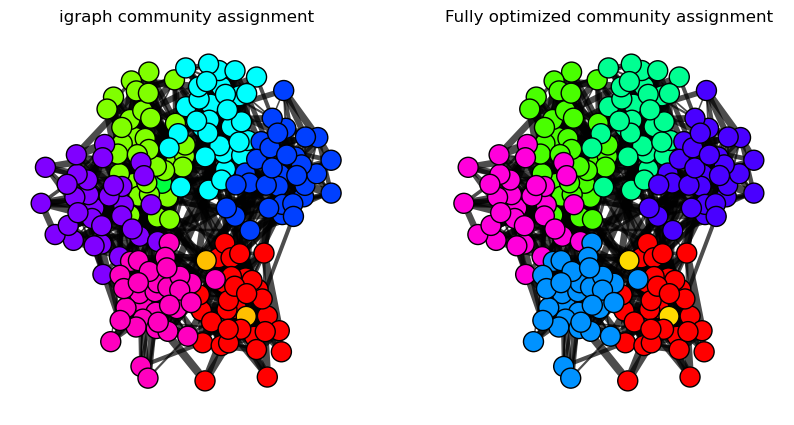

In [11]:
layout = g_test.layout('fr')
comms_ig = g_test.community_infomap(edge_weights=g_test.es['weight'], vertex_weights=None, trials=10)
fig, ax = plt.subplots(ncols=2, figsize = (10, 5))
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=comms_ig.membership, skipLayout=True), target=ax[0])
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=comms, skipLayout=True), target=ax[1])
ax[0].set_title("igraph community assignment")
ax[1].set_title("Fully optimized community assignment")
plt.show()

In [12]:
compare_partitions(comms, comms_ig.membership)
print("custom description length: ", inf.compute_description_length(g_test, comms))
print("igraph description length: ", comms_ig.codelength)
print("igraph description length w custom computation: ", inf.compute_description_length(g_test, comms_ig.membership))

Comparing partitions:
Partition 1: 7 communities
Partition 2: 8 communities
Normalized Mututal Information: 0.9939
Adjusted Rand Index: 0.9938
custom description length:  6.138568212614598
igraph description length:  6.137013960511083
igraph description length w custom computation:  6.137013960511084


and comparing to the ground truth:

In [13]:
ground_truth = g_test.vs["community"]
compare_partitions(comms, ground_truth)
print("custom description length: ", inf.compute_description_length(g_test, comms))
print("ground truth description length: ", inf.compute_description_length(g_test, ground_truth))

Comparing partitions:
Partition 1: 7 communities
Partition 2: 6 communities
Normalized Mututal Information: 0.9895
Adjusted Rand Index: 0.9881
custom description length:  6.138568212614598
ground truth description length:  6.1391412735920206


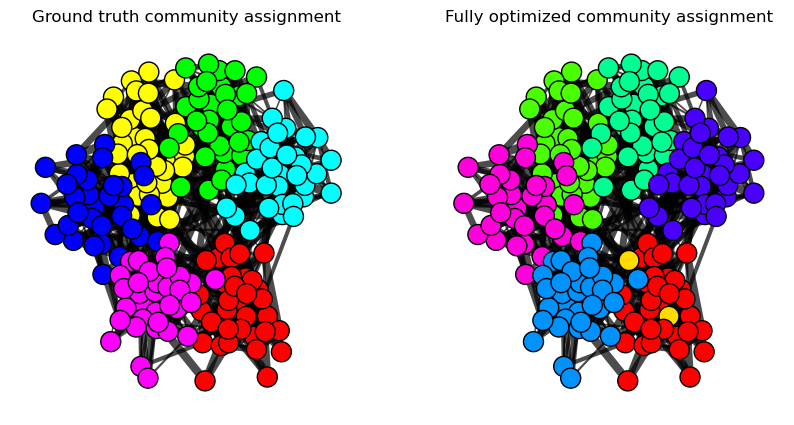

In [14]:
fig, ax = plt.subplots(ncols=2, figsize = (10, 5))
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=ground_truth, skipLayout=True), target=ax[0])
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=comms, skipLayout=True), target=ax[1])
ax[0].set_title("Ground truth community assignment")
ax[1].set_title("Fully optimized community assignment")
plt.show()

#### Directed test network:

In [15]:
comms = search_community_partition(g_test_directed, verbose=True)

--- Running community search ---------------------------------------
Input Graph: 100 nodes, 441 edges

--- Run 1/10:  Starting community partition search... -------
Starting from description length L = 8.281362569219178 bits (with trivial parititon)

--- Level 0 ------------------------------
    Current Graph: 100 nodes, 441 edges
Initialising node movement optimization with each node in its own community.
Starting from description length: 8.281362569219178
Current best description length: 6.371133969797902
Number of nodes moved this iteration: 77
Continuing optimization.
Current best description length: 6.069829705058084
Number of nodes moved this iteration: 21
Continuing optimization.
Current best description length: 5.990239359303988
Number of nodes moved this iteration: 8
Continuing optimization.
Current best description length: 5.990239359303988
Number of nodes moved this iteration: 0
Optimization finished!
Final number of communities: 24
Final description length: 5.990239359303

Comparing to the `igraph` implementation:

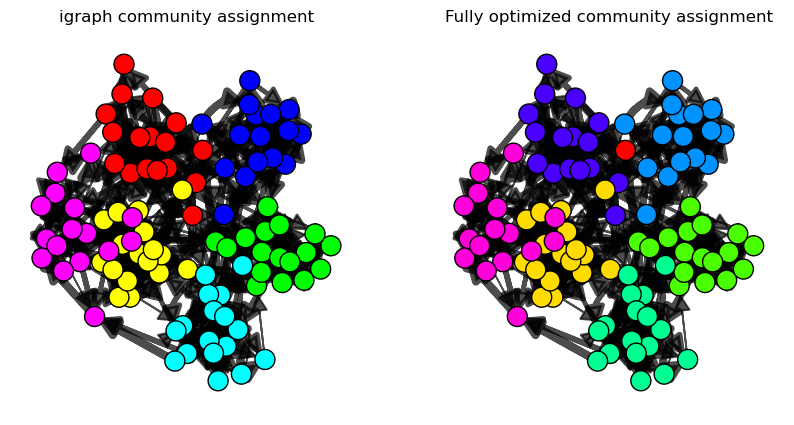

In [16]:
layout = g_test_directed.layout('fr')
comms_ig = g_test_directed.community_infomap(edge_weights=g_test_directed.es['weight'], vertex_weights=None, trials=10)
fig, ax = plt.subplots(ncols=2, figsize = (10, 5))
ig.plot(g_test_directed, layout=layout, **inf.visual_community_colors(g_test_directed, communities=comms_ig.membership, skipLayout=True), target=ax[0])
ig.plot(g_test_directed, layout=layout, **inf.visual_community_colors(g_test_directed, communities=comms, skipLayout=True), target=ax[1])
ax[0].set_title("igraph community assignment")
ax[1].set_title("Fully optimized community assignment")
plt.show()

In [17]:
compare_partitions(comms, comms_ig.membership)
print("custom description length: ", inf.compute_description_length(g_test_directed, comms))
print("igraph description length: ", comms_ig.codelength)
print("igraph description length w custom computation: ", inf.compute_description_length(g_test_directed, comms_ig.membership))

Comparing partitions:
Partition 1: 7 communities
Partition 2: 6 communities
Normalized Mututal Information: 0.9895
Adjusted Rand Index: 0.9878
custom description length:  5.443503936654643
igraph description length:  5.056017399000944
igraph description length w custom computation:  5.460201789370101


and to the ground truth:

In [22]:
ground_truth = g_test_directed.vs["community"]
compare_partitions(comms, ground_truth)
print("custom description length: ", inf.compute_description_length(g_test_directed, comms))
print("ground truth description length: ", inf.compute_description_length(g_test_directed, ground_truth))

Comparing partitions:
Partition 1: 7 communities
Partition 2: 6 communities
Normalized Mututal Information: 0.9895
Adjusted Rand Index: 0.9878
custom description length:  5.443503936654643
ground truth description length:  5.460201789370101


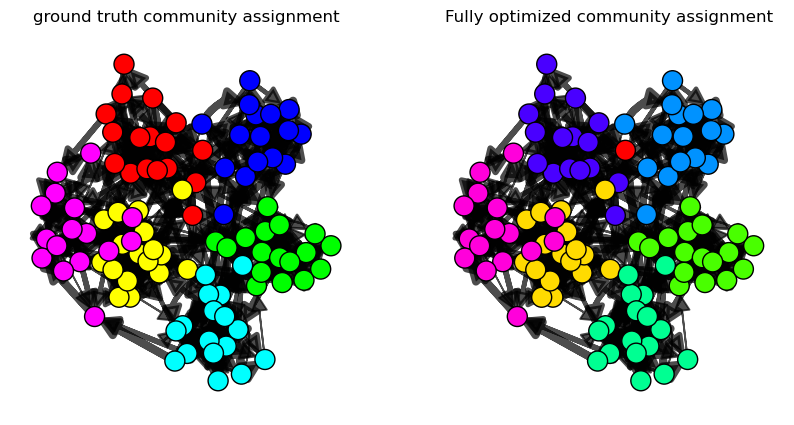

In [19]:
fig, ax = plt.subplots(ncols=2, figsize = (10, 5))
ig.plot(g_test_directed, layout=layout, **inf.visual_community_colors(g_test_directed, communities=ground_truth, skipLayout=True), target=ax[0])
ig.plot(g_test_directed, layout=layout, **inf.visual_community_colors(g_test_directed, communities=comms, skipLayout=True), target=ax[1])
ax[0].set_title("ground truth community assignment")
ax[1].set_title("Fully optimized community assignment")
plt.show()

#### Timing the full search algorithm:
This time, including 10 restarts:

In [20]:
%timeit -r50 search_community_partition(g_test, num_restarts=10)

2min 42s ± 1min 13s per loop (mean ± std. dev. of 50 runs, 1 loop each)


In [21]:
%timeit -r50 search_community_partition(g_test_directed, num_restarts=10)

30 s ± 1.58 s per loop (mean ± std. dev. of 50 runs, 1 loop each)
